In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rrokon/ev-demand-dataset-sales-trends-and-infrastructure/ev_trends_monthly.csv
/kaggle/input/datasets/rrokon/ev-demand-dataset-sales-trends-and-infrastructure/fuel_prices_monthly.csv
/kaggle/input/datasets/rrokon/ev-demand-dataset-sales-trends-and-infrastructure/README.md
/kaggle/input/datasets/rrokon/ev-demand-dataset-sales-trends-and-infrastructure/ev_market_master.csv
/kaggle/input/datasets/rrokon/ev-demand-dataset-sales-trends-and-infrastructure/ev_sales_brands.csv
/kaggle/input/datasets/rrokon/ev-demand-dataset-sales-trends-and-infrastructure/ev_charging_monthly.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans'
})
PALETTE = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800', '#00BCD4', '#E91E63', '#607D8B']
sns.set_palette(PALETTE)
print('✅ Libraries loaded')

✅ Libraries loaded


In [3]:
import os
BASE = '/kaggle/input/datasets/rrokon/ev-demand-dataset-sales-trends-and-infrastructure/' 
if not os.path.exists(BASE):
    BASE = '.'  # fallback: same directory

def add_date(df):
    """Build a 'date' column from year + month columns (works for all files)."""
    df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
    return df

# master already has a 'date' column; others only have year+month
master   = pd.read_csv(f'{BASE}/ev_market_master.csv')
master['date'] = pd.to_datetime(master['date'])   # parse existing date col

brands   = add_date(pd.read_csv(f'{BASE}/ev_sales_brands.csv'))
trends   = add_date(pd.read_csv(f'{BASE}/ev_trends_monthly.csv'))
chargers = add_date(pd.read_csv(f'{BASE}/ev_charging_monthly.csv'))
fuel     = add_date(pd.read_csv(f'{BASE}/fuel_prices_monthly.csv'))

# Pivot trends from long (keyword rows) to wide (keyword columns)
if 'keyword' in trends.columns:
    trends = trends.pivot_table(
        index=['country', 'date', 'year', 'month'],
        columns='keyword', values='trend_score'
    ).reset_index()
    trends.columns.name = None
    # Rename to match master column names
    kw_map = {
        'electric car'    : 'trend_electric_car',
        'electric vehicle': 'trend_electric_vehicle',
        'BYD'             : 'trend_byd',
        'Tesla'           : 'trend_tesla',
        'EV charging'     : 'trend_ev_charging',
    }
    trends = trends.rename(columns={k: v for k, v in kw_map.items() if k in trends.columns})

print(f'master   : {master.shape}')
print(f'brands   : {brands.shape}')
print(f'trends   : {trends.shape}')
print(f'chargers : {chargers.shape}')
print(f'fuel     : {fuel.shape}')
print('\ntrends columns:', list(trends.columns))

master   : (420, 25)
brands   : (420, 9)
trends   : (584, 9)
chargers : (456, 9)
fuel     : (480, 7)

trends columns: ['country', 'date', 'year', 'month', 'trend_byd', 'trend_ev_charging', 'trend_tesla', 'trend_electric_car', 'trend_electric_vehicle']


In [4]:
master.head()

,country,brand,drivetrain_type,year,month,units_sold,frequency,source,trend_byd,trend_ev_charging,...,total_chargers_cumulative,gasoline_price_usd_per_liter,units_sold_lag1,units_sold_lag3,units_sold_lag12,units_sold_rolling3,units_sold_yoy_growth,quarter,date,date_str
0,China,BYD,BEV+PHEV,2020,1,24840,monthly_est,brand_reports,2.75,NaN,...,784000.0,0.78,NaN,NaN,NaN,24840.0,NaN,1,2020-01-01,2020-01
1,China,BYD,BEV+PHEV,2020,2,24840,monthly_est,brand_reports,0.00,NaN,...,784000.0,0.78,24840.0,NaN,NaN,24840.0,NaN,1,2020-02-01,2020-02
2,China,BYD,BEV+PHEV,2020,3,24840,monthly_est,brand_reports,0.00,NaN,...,784000.0,0.78,24840.0,NaN,NaN,24840.0,NaN,1,2020-03-01,2020-03
3,China,BYD,BEV+PHEV,2020,4,29880,monthly_est,brand_reports,0.00,NaN,...,784000.0,0.80,24840.0,24840.0,NaN,26520.0,NaN,2,2020-04-01,2020-04
4,China,BYD,BEV+PHEV,2020,5,29880,monthly_est,brand_reports,0.00,NaN,...,784000.0,0.80,29880.0,24840.0,NaN,28200.0,NaN,2,2020-05-01,2020-05


In [5]:
print('=== Basic Info ===')
print(f"Countries  : {sorted(master['country'].unique())}")
print(f"Brands     : {sorted(master['brand'].unique())}")
print(f"Period     : {master['date'].min().date()} → {master['date'].max().date()}")
print(f"Missing %  :")
print((master.isnull().mean() * 100).round(1).to_string())

=== Basic Info ===
Countries  : ['China', 'France', 'Germany', 'India', 'Netherlands', 'Norway', 'USA', 'United Kingdom']
Brands     : ['All', 'BYD', 'Tesla', 'VW']
Period     : 2019-01-01 → 2023-12-01
Missing %  :
country                          0.0
brand                            0.0
drivetrain_type                  0.0
year                             0.0
month                            0.0
units_sold                       0.0
frequency                        0.0
source                           0.0
trend_byd                        0.0
trend_ev_charging                2.6
trend_tesla                      0.0
trend_electric_car               0.0
trend_electric_vehicle           2.6
slow_chargers_cumulative         5.7
fast_chargers_cumulative         5.7
total_chargers_cumulative        5.7
gasoline_price_usd_per_liter     0.0
units_sold_lag1                  2.1
units_sold_lag3                  6.4
units_sold_lag12                25.7
units_sold_rolling3              0.0
units_so

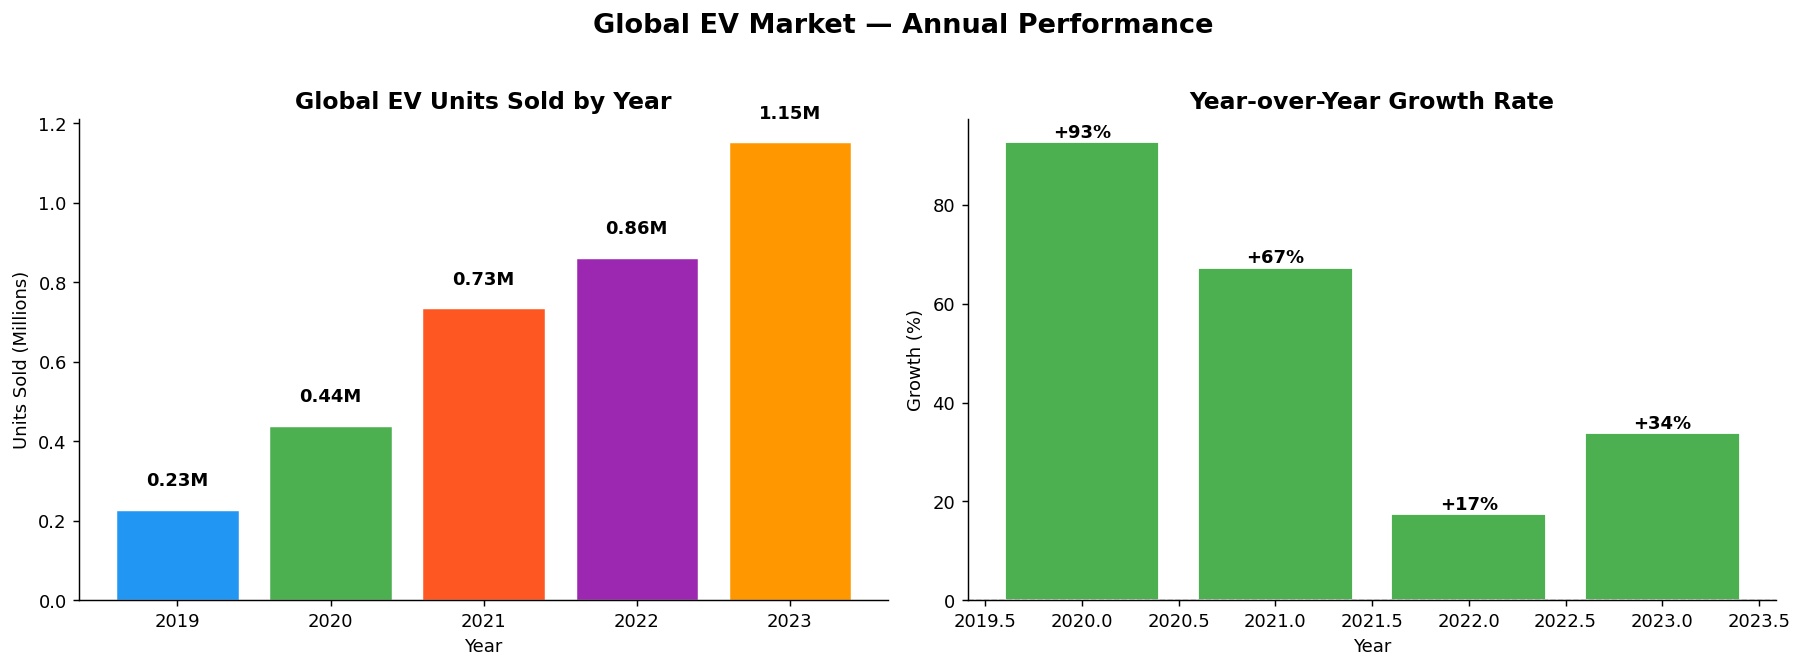

 year  units_sold   yoy_pct
 2019      227820       NaN
 2020      438996 92.694232
 2021      734484 67.309953
 2022      861912 17.349323
 2023     1152768 33.745440


In [6]:
# Annual total sales (All brands)
annual_all = (
    master[master['brand'] == 'All']
    .groupby('year')['units_sold'].sum()
    .reset_index()
)
annual_all['yoy_pct'] = annual_all['units_sold'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — total units
bars = axes[0].bar(annual_all['year'], annual_all['units_sold'] / 1e6,
                   color=PALETTE[:5], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, annual_all['units_sold']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{val/1e6:.2f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Global EV Units Sold by Year')
axes[0].set_ylabel('Units Sold (Millions)')
axes[0].set_xlabel('Year')

# YoY growth
yoy = annual_all.dropna(subset=['yoy_pct'])
colors_yoy = ['#4CAF50' if v >= 0 else '#F44336' for v in yoy['yoy_pct']]
axes[1].bar(yoy['year'], yoy['yoy_pct'], color=colors_yoy, edgecolor='white')
for i, (_, row) in enumerate(yoy.iterrows()):
    axes[1].text(row['year'], row['yoy_pct'] + 1,
                 f"+{row['yoy_pct']:.0f}%" if row['yoy_pct'] >= 0 else f"{row['yoy_pct']:.0f}%",
                 ha='center', fontsize=10, fontweight='bold')
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[1].set_title('Year-over-Year Growth Rate')
axes[1].set_ylabel('Growth (%)')
axes[1].set_xlabel('Year')

plt.suptitle('Global EV Market — Annual Performance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(annual_all.to_string(index=False))

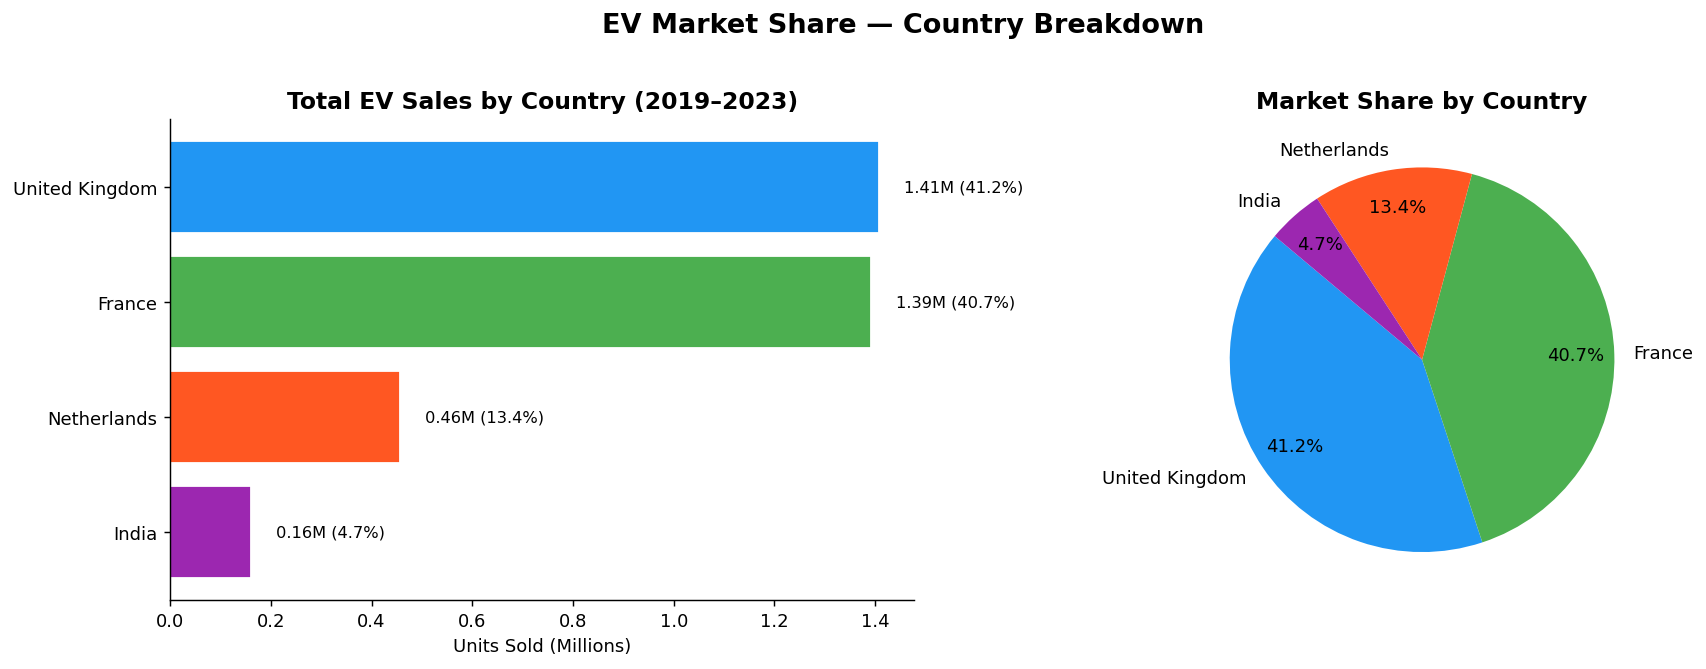

In [7]:
# Total sales by country
country_total = (
    master[master['brand'] == 'All']
    .groupby('country')['units_sold'].sum()
    .sort_values(ascending=False)
    .reset_index()
)
country_total['share_pct'] = country_total['units_sold'] / country_total['units_sold'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Horizontal bar
axes[0].barh(country_total['country'], country_total['units_sold'] / 1e6,
             color=PALETTE[:len(country_total)], edgecolor='white')
for i, (_, row) in enumerate(country_total.iterrows()):
    axes[0].text(row['units_sold'] / 1e6 + 0.05, i,
                 f"{row['units_sold']/1e6:.2f}M ({row['share_pct']:.1f}%)",
                 va='center', fontsize=9)
axes[0].invert_yaxis()
axes[0].set_title('Total EV Sales by Country (2019–2023)')
axes[0].set_xlabel('Units Sold (Millions)')

# Pie chart for market share
axes[1].pie(country_total['units_sold'], labels=country_total['country'],
            colors=PALETTE[:len(country_total)], autopct='%1.1f%%',
            startangle=140, pctdistance=0.8)
axes[1].set_title('Market Share by Country')

plt.suptitle('EV Market Share — Country Breakdown', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

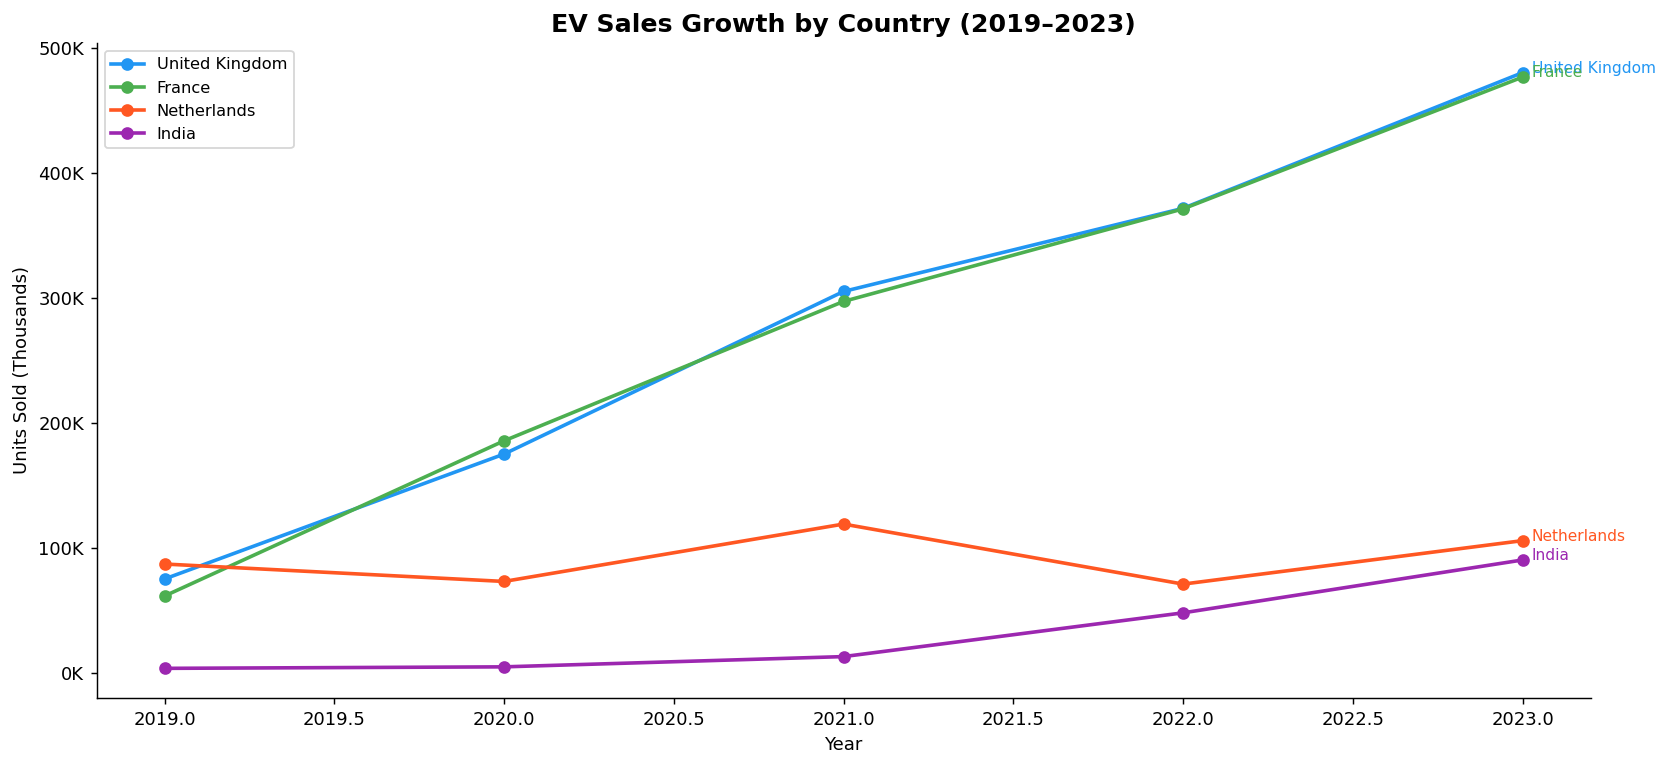

In [8]:
# Country growth trends over time
country_year = (
    master[master['brand'] == 'All']
    .groupby(['country', 'year'])['units_sold'].sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 6))
for i, country in enumerate(country_total['country']):
    sub = country_year[country_year['country'] == country]
    ax.plot(sub['year'], sub['units_sold'] / 1e3, marker='o',
            label=country, color=PALETTE[i], linewidth=2)
    ax.annotate(country, xy=(sub['year'].iloc[-1], sub['units_sold'].iloc[-1] / 1e3),
                xytext=(5, 0), textcoords='offset points', fontsize=8.5, color=PALETTE[i])

ax.set_title('EV Sales Growth by Country (2019–2023)', fontsize=14, fontweight='bold')
ax.set_ylabel('Units Sold (Thousands)')
ax.set_xlabel('Year')
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
plt.tight_layout()
plt.show()

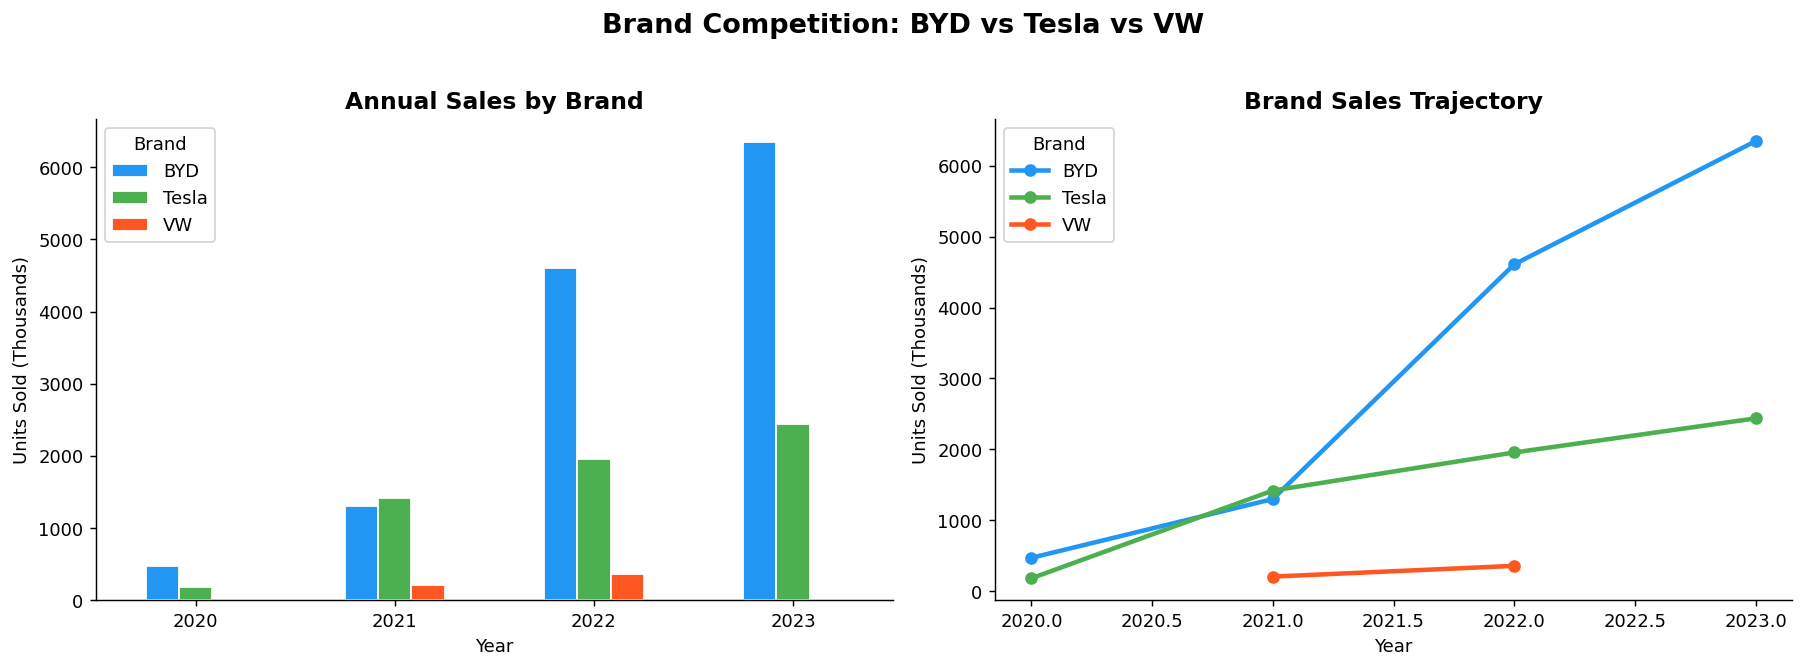


Total Sales by Brand (2019–2023):
brand
BYD      12,725,595
Tesla     5,990,736
VW          559,893


In [9]:
# Brand sales comparison
brand_year = (
    master[master['brand'].isin(['BYD', 'Tesla', 'VW'])]
    .groupby(['brand', 'year'])['units_sold'].sum()
    .reset_index()
)

brand_pivot = brand_year.pivot(index='year', columns='brand', values='units_sold').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar
brand_pivot.div(1e3).plot(kind='bar', stacked=False, ax=axes[0],
                          color=['#2196F3', '#4CAF50', '#FF5722'], edgecolor='white')
axes[0].set_title('Annual Sales by Brand')
axes[0].set_ylabel('Units Sold (Thousands)')
axes[0].set_xlabel('Year')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Brand')

# Line chart — brand trajectory
brand_colors = {'BYD': '#2196F3', 'Tesla': '#4CAF50', 'VW': '#FF5722'}
for brand in ['BYD', 'Tesla', 'VW']:
    sub = brand_year[brand_year['brand'] == brand]
    axes[1].plot(sub['year'], sub['units_sold'] / 1e3, marker='o',
                 label=brand, color=brand_colors[brand], linewidth=2.5)
axes[1].set_title('Brand Sales Trajectory')
axes[1].set_ylabel('Units Sold (Thousands)')
axes[1].set_xlabel('Year')
axes[1].legend(title='Brand')

plt.suptitle('Brand Competition: BYD vs Tesla vs VW', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nTotal Sales by Brand (2019–2023):')
print(master[master['brand'].isin(['BYD', 'Tesla', 'VW'])]
      .groupby('brand')['units_sold'].sum()
      .sort_values(ascending=False)
      .apply(lambda x: f'{x:,.0f}')
      .to_string())

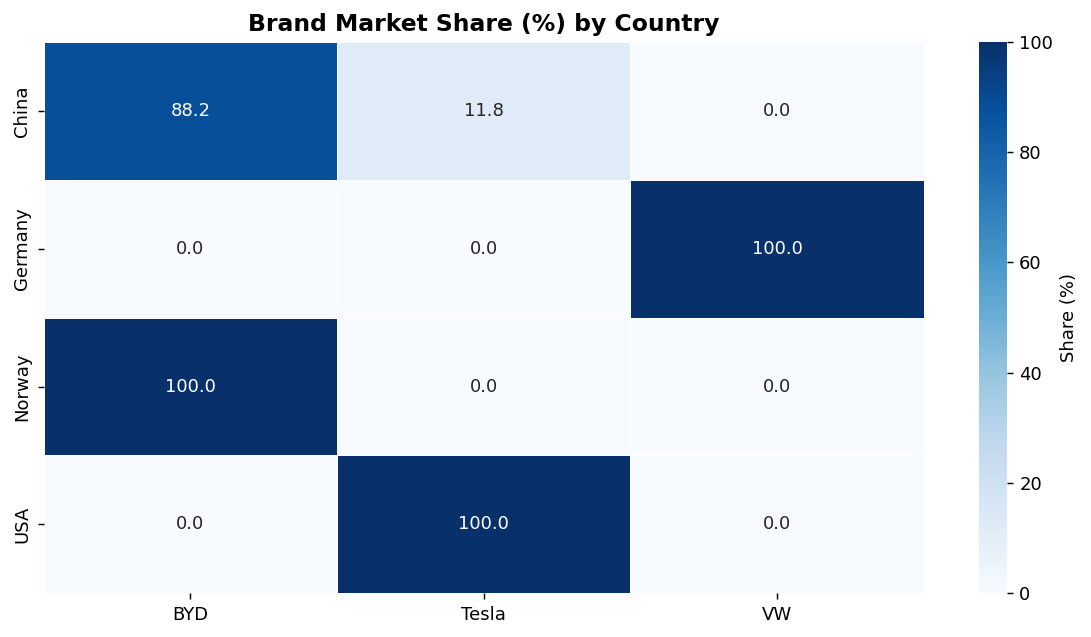

In [10]:
# Brand market share by country (heatmap)
brand_country = (
    master[master['brand'].isin(['BYD', 'Tesla', 'VW'])]
    .groupby(['country', 'brand'])['units_sold'].sum()
    .reset_index()
    .pivot(index='country', columns='brand', values='units_sold')
    .fillna(0)
)

# Normalize to % of total per country
brand_country_pct = brand_country.div(brand_country.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(brand_country_pct.round(1), annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Share (%)'})
ax.set_title('Brand Market Share (%) by Country', fontsize=13, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

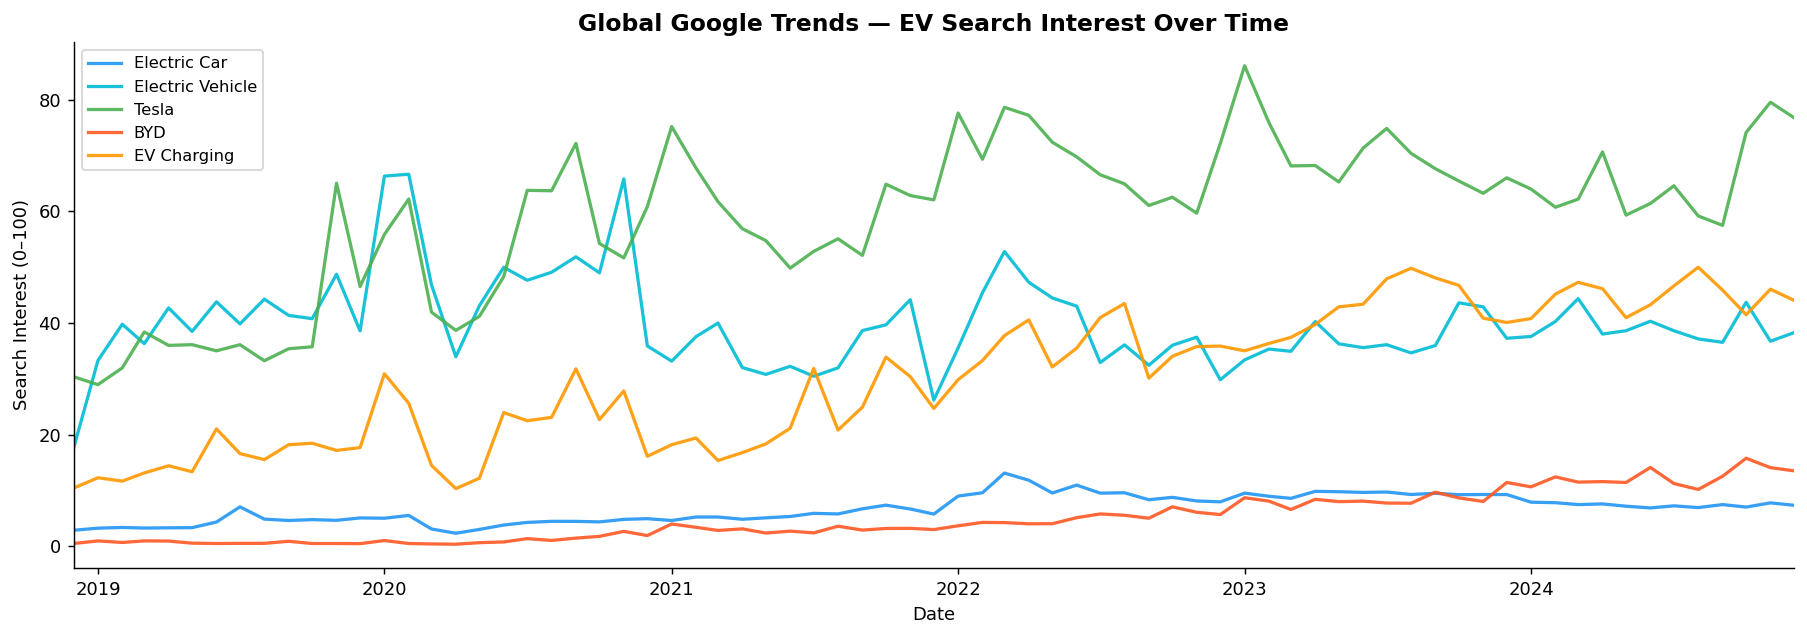

In [11]:
# Global average search interest over time 
trend_cols = ['trend_electric_car', 'trend_electric_vehicle', 'trend_tesla',
              'trend_byd', 'trend_ev_charging']
trend_labels = ['Electric Car', 'Electric Vehicle', 'Tesla', 'BYD', 'EV Charging']
trend_colors = ['#2196F3', '#00BCD4', '#4CAF50', '#FF5722', '#FF9800']

trends_agg = trends.groupby('date')[trend_cols].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for col, label, color in zip(trend_cols, trend_labels, trend_colors):
    if col in trends_agg.columns:
        ax.plot(trends_agg['date'], trends_agg[col],
                label=label, color=color, linewidth=1.8, alpha=0.9)

ax.set_title('Global Google Trends — EV Search Interest Over Time', fontsize=13, fontweight='bold')
ax.set_ylabel('Search Interest (0–100)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(trends_agg['date'].min(), trends_agg['date'].max())
plt.tight_layout()
plt.show()

In [12]:
# Trends vs Sales Correlation
all_sales = master[master['brand'] == 'All'].copy()
merged_tr = all_sales.merge(
    trends_agg, on='date', how='inner', suffixes=('', '_trend')
)

print('Pearson Correlation — Search Interest vs Units Sold:')
print('-' * 45)
for col, label in zip(trend_cols, trend_labels):
    valid = merged_tr[['units_sold', col]].dropna()
    if len(valid) > 5:
        r, p = pearsonr(valid['units_sold'], valid[col])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f'  {label:<22}: r = {r:+.3f}  p = {p:.4f} {sig}')

Pearson Correlation — Search Interest vs Units Sold:
---------------------------------------------
  Electric Car          : r = +0.157  p = 0.0148 *
  Electric Vehicle      : r = -0.041  p = 0.5282 
  Tesla                 : r = +0.591  p = 0.0000 ***
  BYD                   : r = +0.010  p = 0.8764 
  EV Charging           : r = +0.521  p = 0.0000 ***


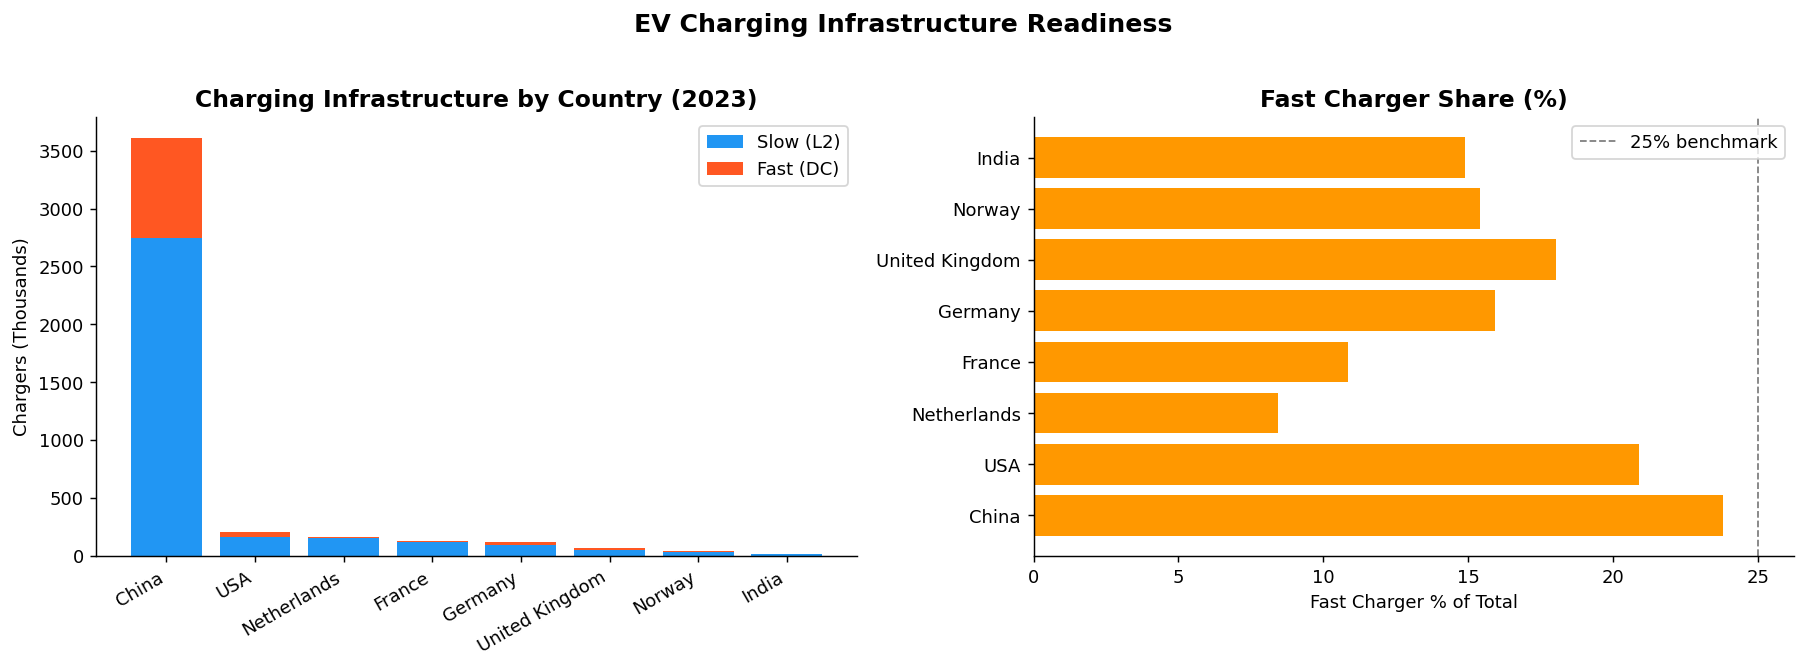

In [13]:
# Charger growth by country
charger_latest = chargers.groupby('country').apply(
    lambda x: x.sort_values('date').iloc[-1]
).reset_index(drop=True)[['country', 'slow_chargers_cumulative',
                           'fast_chargers_cumulative', 'total_chargers_cumulative']]

charger_latest = charger_latest.sort_values('total_chargers_cumulative', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar — slow vs fast
x = range(len(charger_latest))
axes[0].bar(x, charger_latest['slow_chargers_cumulative'] / 1e3,
            label='Slow (L2)', color='#2196F3')
axes[0].bar(x, charger_latest['fast_chargers_cumulative'] / 1e3,
            bottom=charger_latest['slow_chargers_cumulative'] / 1e3,
            label='Fast (DC)', color='#FF5722')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(charger_latest['country'], rotation=30, ha='right')
axes[0].set_title('Charging Infrastructure by Country (2023)')
axes[0].set_ylabel('Chargers (Thousands)')
axes[0].legend()

# Fast charger share
charger_latest['fast_share'] = (charger_latest['fast_chargers_cumulative'] /
                                 charger_latest['total_chargers_cumulative'] * 100)
axes[1].barh(charger_latest['country'], charger_latest['fast_share'],
             color=['#FF5722' if v > 25 else '#FF9800' for v in charger_latest['fast_share']])
axes[1].axvline(25, color='gray', linestyle='--', linewidth=1, label='25% benchmark')
axes[1].set_title('Fast Charger Share (%)')
axes[1].set_xlabel('Fast Charger % of Total')
axes[1].legend()

plt.suptitle('EV Charging Infrastructure Readiness', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

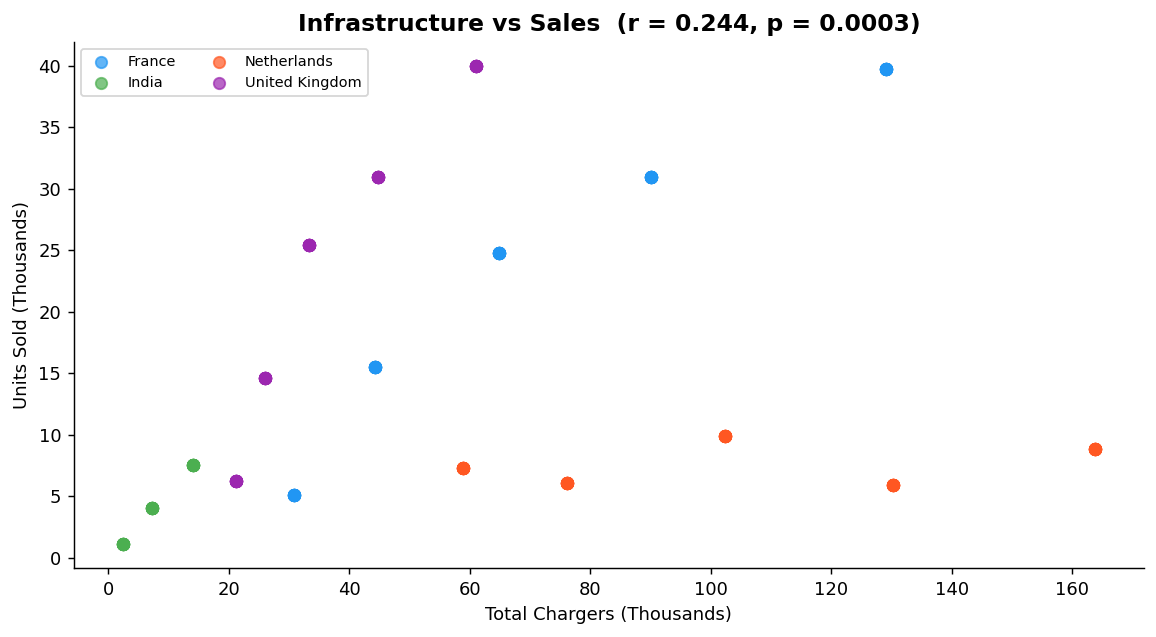

In [14]:
_charger_cols = ['slow_chargers_cumulative', 'fast_chargers_cumulative', 'total_chargers_cumulative']
_all_sales_clean = all_sales.drop(columns=[c for c in _charger_cols if c in all_sales.columns])
infra_sales = _all_sales_clean.merge(
    chargers[['country', 'date', 'total_chargers_cumulative']],
    on=['country', 'date'], how='inner'
).dropna(subset=['total_chargers_cumulative', 'units_sold'])

fig, ax = plt.subplots(figsize=(9, 5))
for i, country in enumerate(infra_sales['country'].unique()):
    sub = infra_sales[infra_sales['country'] == country]
    ax.scatter(sub['total_chargers_cumulative'] / 1e3, sub['units_sold'] / 1e3,
               label=country, color=PALETTE[i], alpha=0.7, s=40)

r, p = pearsonr(infra_sales['total_chargers_cumulative'], infra_sales['units_sold'])
ax.set_title(f'Infrastructure vs Sales  (r = {r:.3f}, p = {p:.4f})', fontweight='bold')
ax.set_xlabel('Total Chargers (Thousands)')
ax.set_ylabel('Units Sold (Thousands)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

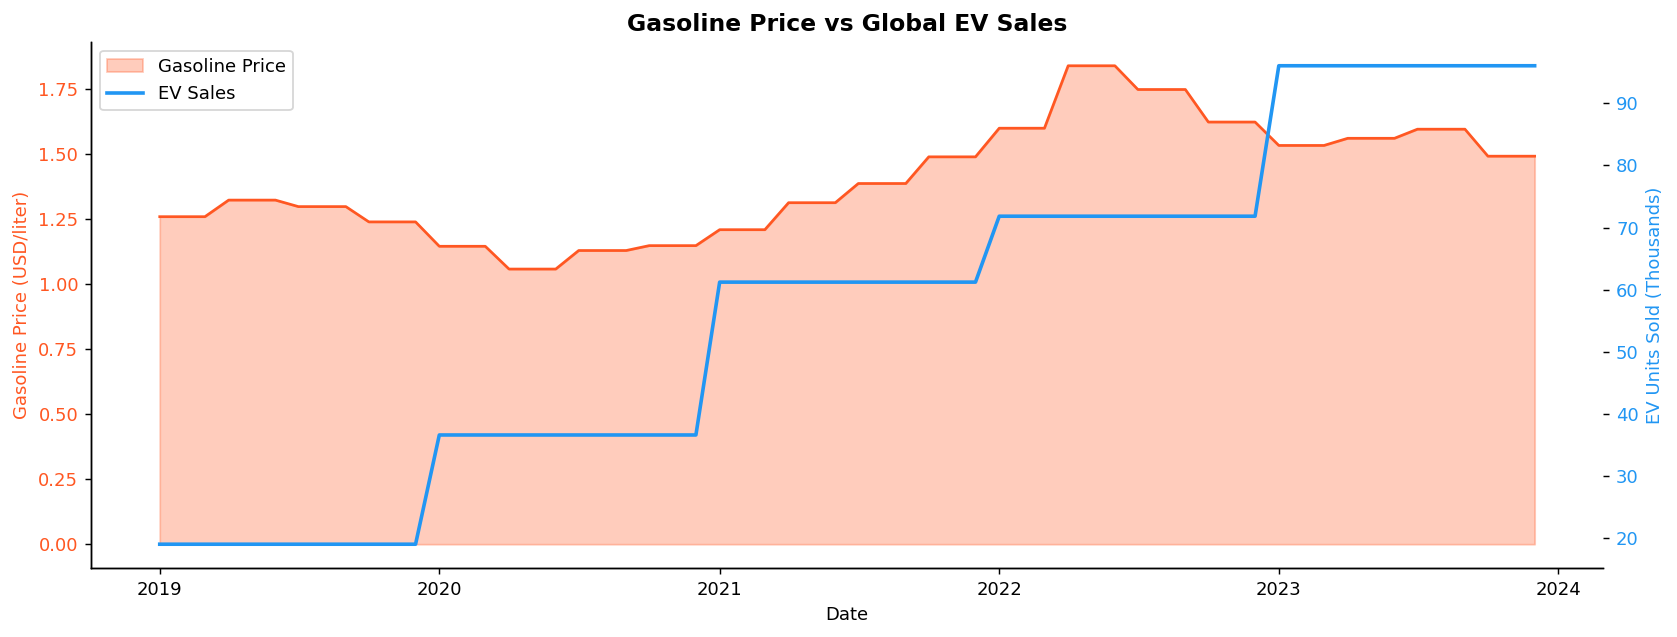


Correlation (Fuel Price vs EV Sales): r = 0.698, p = 0.0000


In [15]:
# Fuel price trend
fuel_avg = fuel.groupby('date')['gasoline_price_usd_per_liter'].mean().reset_index()

all_sales_monthly = (
    all_sales.groupby('date')['units_sold'].sum().reset_index()
)

fuel_merged = fuel_avg.merge(all_sales_monthly, on='date', how='inner')

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.fill_between(fuel_merged['date'], fuel_merged['gasoline_price_usd_per_liter'],
                  alpha=0.3, color='#FF5722', label='Gasoline Price')
ax1.plot(fuel_merged['date'], fuel_merged['gasoline_price_usd_per_liter'],
          color='#FF5722', linewidth=1.5)
ax1.set_ylabel('Gasoline Price (USD/liter)', color='#FF5722')
ax1.tick_params(axis='y', labelcolor='#FF5722')

ax2.plot(fuel_merged['date'], fuel_merged['units_sold'] / 1e3,
          color='#2196F3', linewidth=2, label='EV Sales')
ax2.set_ylabel('EV Units Sold (Thousands)', color='#2196F3')
ax2.tick_params(axis='y', labelcolor='#2196F3')

ax1.set_title('Gasoline Price vs Global EV Sales', fontsize=13, fontweight='bold')
ax1.set_xlabel('Date')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

r, p = pearsonr(fuel_merged['gasoline_price_usd_per_liter'], fuel_merged['units_sold'])
print(f'\nCorrelation (Fuel Price vs EV Sales): r = {r:.3f}, p = {p:.4f}')

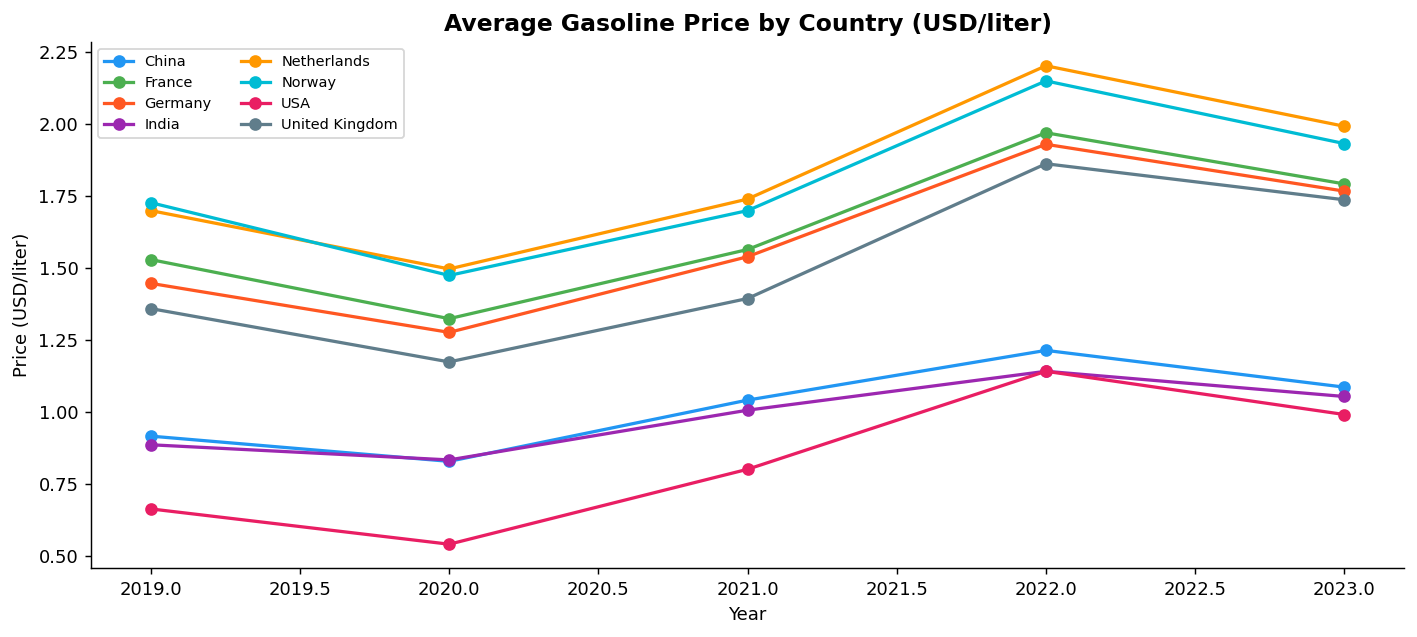

In [16]:
# Fuel price by country
fuel_country_avg = (
    fuel.groupby(['country', 'year'])['gasoline_price_usd_per_liter'].mean()
    .reset_index()
    .pivot(index='year', columns='country', values='gasoline_price_usd_per_liter')
)

fig, ax = plt.subplots(figsize=(11, 5))
for i, col in enumerate(fuel_country_avg.columns):
    ax.plot(fuel_country_avg.index, fuel_country_avg[col],
            marker='o', label=col, color=PALETTE[i % len(PALETTE)], linewidth=1.8)

ax.set_title('Average Gasoline Price by Country (USD/liter)', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD/liter)')
ax.set_xlabel('Year')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

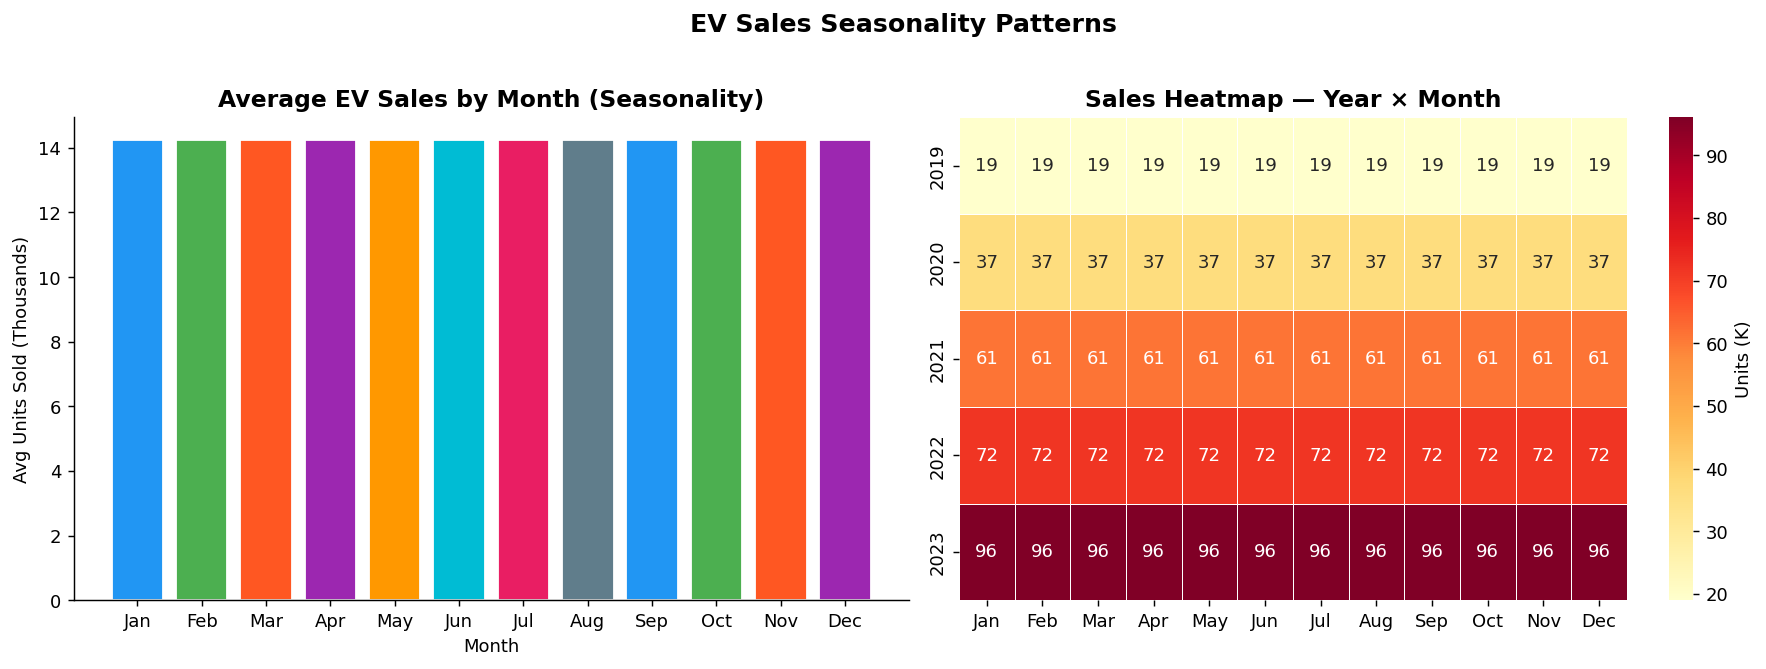

In [17]:
# Monthly seasonality
MONTH_NAMES = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_avg = (
    all_sales.groupby(['month'])['units_sold'].mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 13), monthly_avg['units_sold'] / 1e3,
             color=[PALETTE[i % len(PALETTE)] for i in range(12)],
             edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(MONTH_NAMES)
axes[0].set_title('Average EV Sales by Month (Seasonality)')
axes[0].set_ylabel('Avg Units Sold (Thousands)')
axes[0].set_xlabel('Month')

# Heatmap — Year x Month
pivot_ym = (
    all_sales.groupby(['year', 'month'])['units_sold'].sum()
    .reset_index()
    .pivot(index='year', columns='month', values='units_sold')
)
pivot_ym.columns = MONTH_NAMES

sns.heatmap(pivot_ym / 1e3, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5,
            cbar_kws={'label': 'Units (K)'})
axes[1].set_title('Sales Heatmap — Year × Month')
axes[1].set_ylabel('')
axes[1].set_xlabel('')

plt.suptitle('EV Sales Seasonality Patterns', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

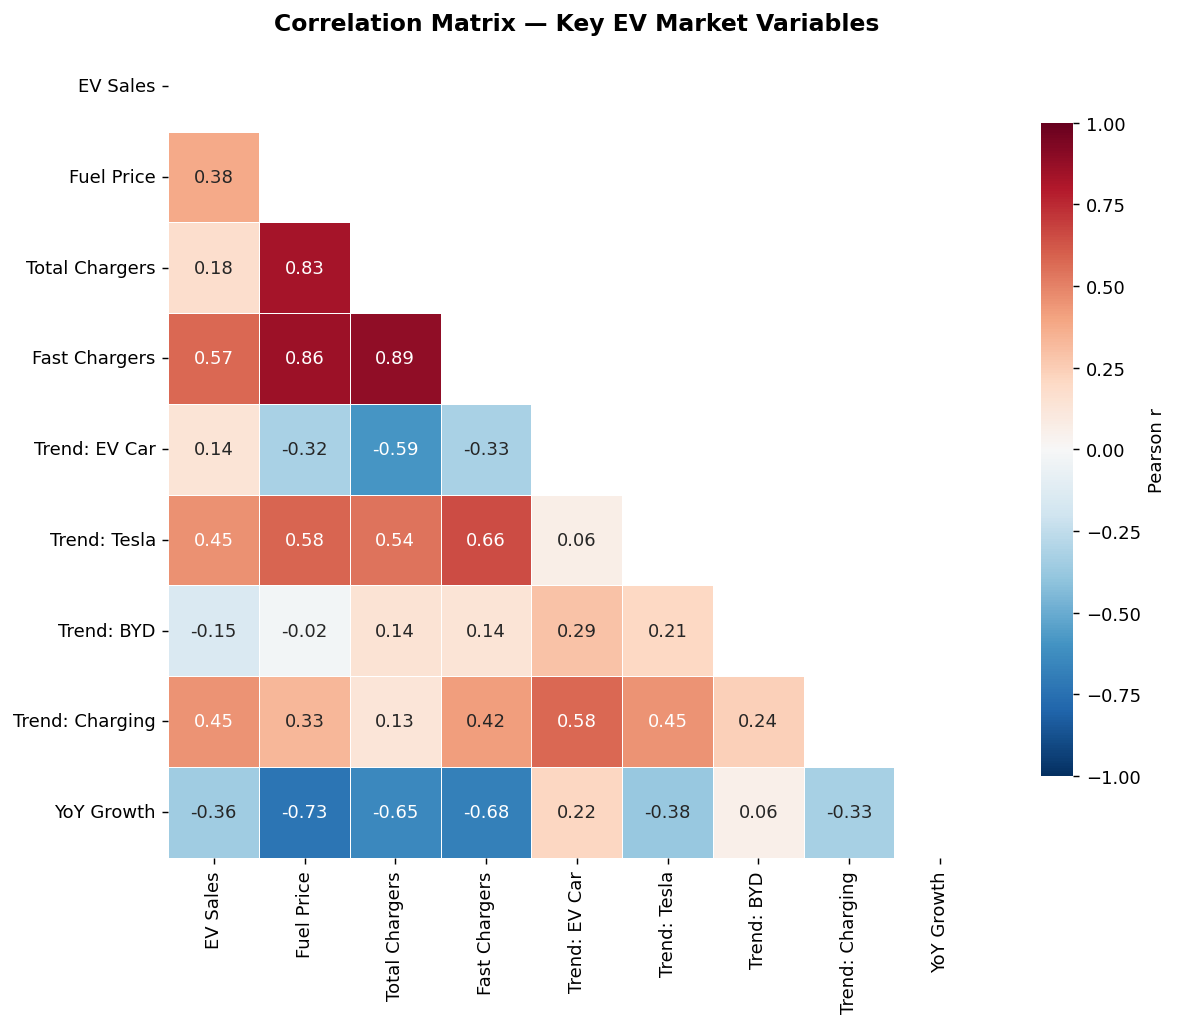

In [18]:
# Full correlation matrix
corr_cols = [
    'units_sold', 'gasoline_price_usd_per_liter',
    'total_chargers_cumulative', 'fast_chargers_cumulative',
    'trend_electric_car', 'trend_tesla', 'trend_byd', 'trend_ev_charging',
    'units_sold_yoy_growth'
]

corr_df = master[master['brand'] == 'All'][corr_cols].dropna()
corr_matrix = corr_df.corr()

# Rename for readability
short_names = {
    'units_sold': 'EV Sales',
    'gasoline_price_usd_per_liter': 'Fuel Price',
    'total_chargers_cumulative': 'Total Chargers',
    'fast_chargers_cumulative': 'Fast Chargers',
    'trend_electric_car': 'Trend: EV Car',
    'trend_tesla': 'Trend: Tesla',
    'trend_byd': 'Trend: BYD',
    'trend_ev_charging': 'Trend: Charging',
    'units_sold_yoy_growth': 'YoY Growth'
}
corr_matrix = corr_matrix.rename(index=short_names, columns=short_names)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1, center=0,
            ax=ax, linewidths=0.5, square=True,
            cbar_kws={'label': 'Pearson r', 'shrink': 0.8})
ax.set_title('Correlation Matrix — Key EV Market Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

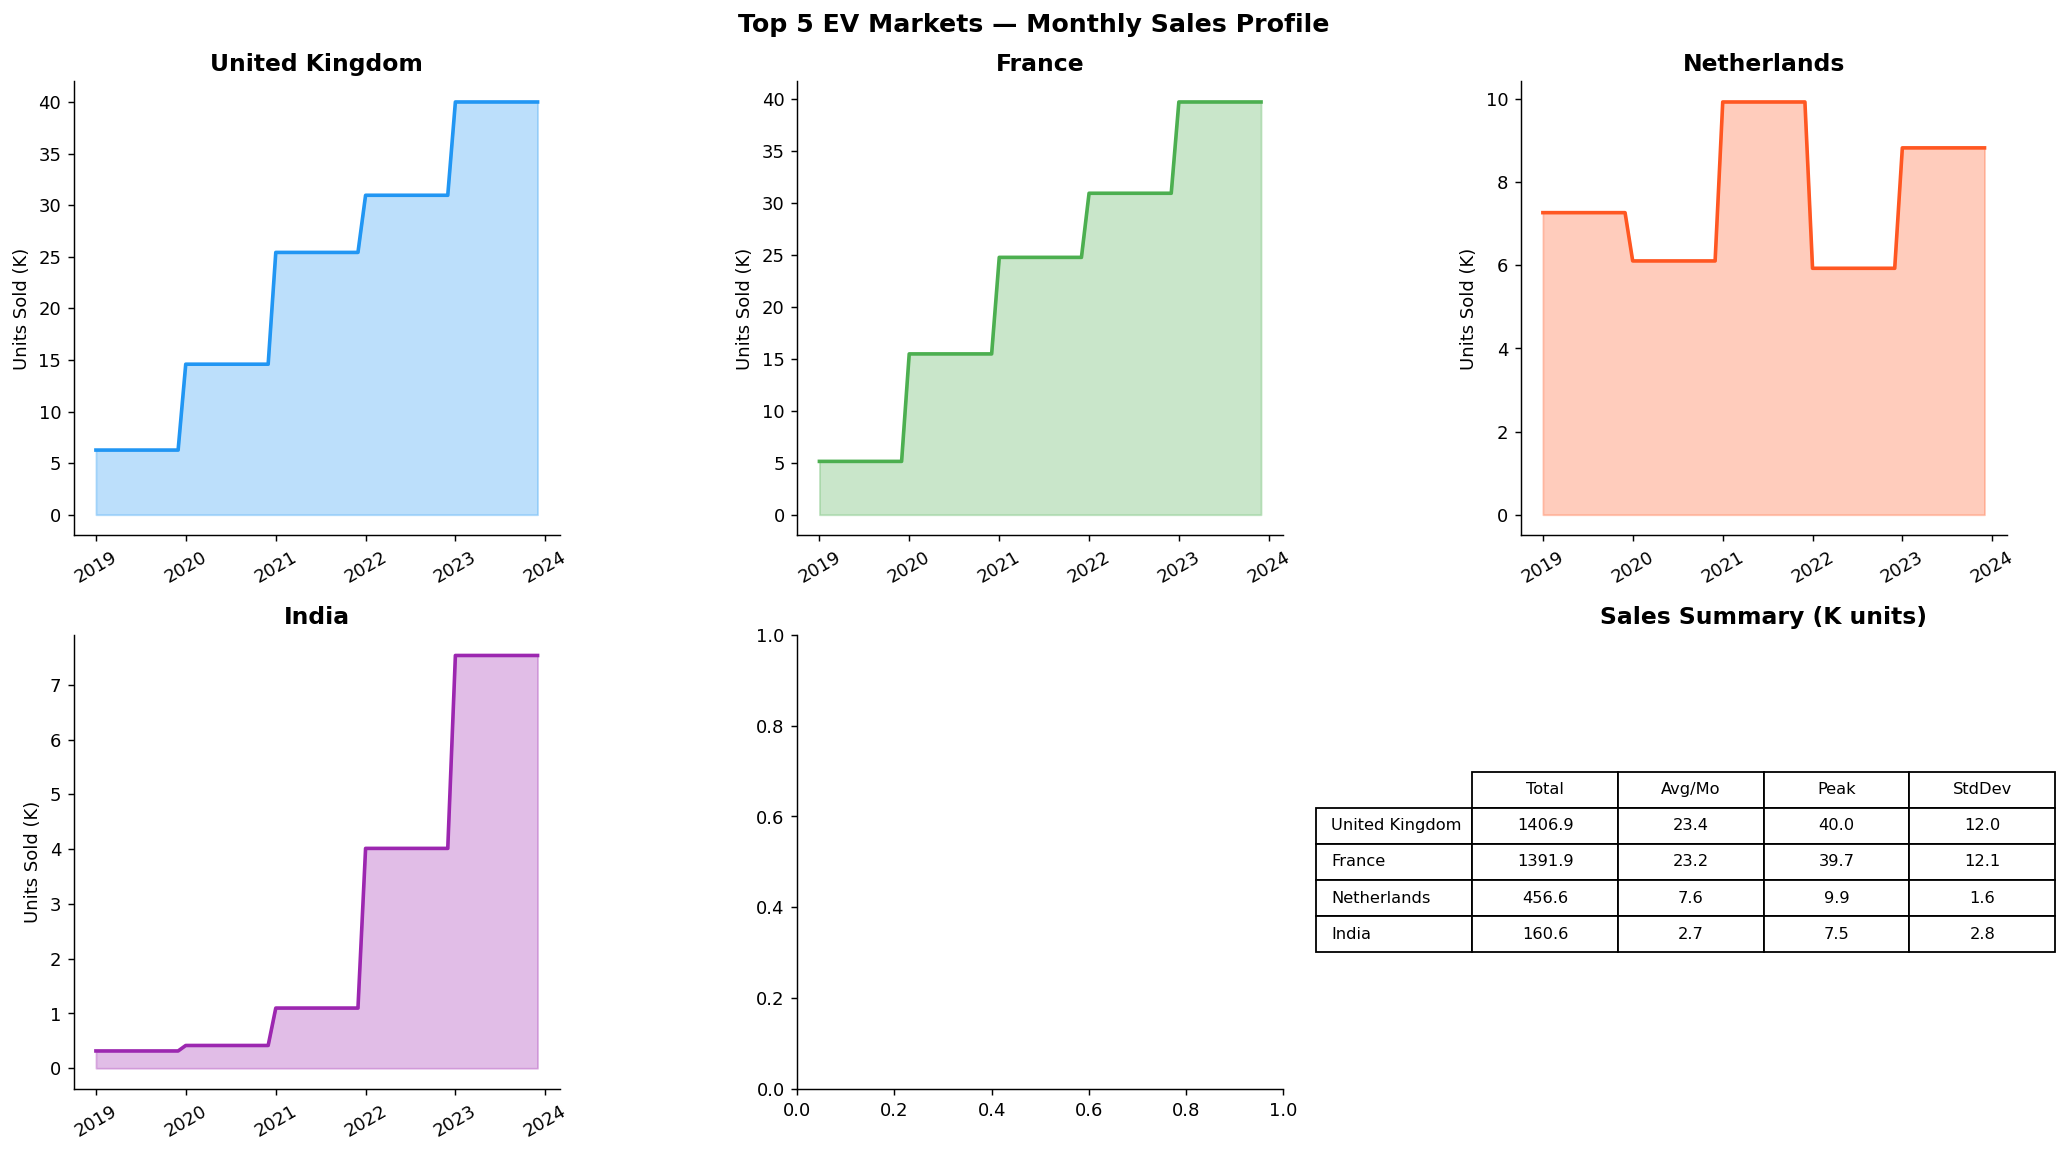

In [19]:
# Top 5 markets monthly trajectory
top5 = country_total.head(5)['country'].tolist()
top5_data = all_sales[all_sales['country'].isin(top5)].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, country in enumerate(top5):
    sub = top5_data[top5_data['country'] == country].sort_values('date')
    axes[i].fill_between(sub['date'], sub['units_sold'] / 1e3,
                          alpha=0.3, color=PALETTE[i])
    axes[i].plot(sub['date'], sub['units_sold'] / 1e3,
                  color=PALETTE[i], linewidth=2)
    axes[i].set_title(country, fontweight='bold')
    axes[i].set_ylabel('Units Sold (K)')
    axes[i].tick_params(axis='x', rotation=30)

# Summary stats in last subplot
summary = (
    top5_data.groupby('country')['units_sold']
    .agg(['sum', 'mean', 'max', 'std'])
    .loc[top5]
    .rename(columns={'sum': 'Total', 'mean': 'Avg/Mo', 'max': 'Peak', 'std': 'StdDev'})
    / 1e3
).round(1)

axes[5].axis('off')
tbl = axes[5].table(
    cellText=summary.values,
    rowLabels=summary.index,
    colLabels=summary.columns,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.5)
axes[5].set_title('Sales Summary (K units)', fontweight='bold')

plt.suptitle('Top 5 EV Markets — Monthly Sales Profile', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Auto-generate summary statistics
total_units   = master[master['brand'] == 'All']['units_sold'].sum()
top_country   = country_total.iloc[0]
top_brand_ser = master[master['brand'].isin(['BYD', 'Tesla', 'VW'])].groupby('brand')['units_sold'].sum()
top_brand     = top_brand_ser.idxmax()

cagr_data     = annual_all.set_index('year')['units_sold']
cagr          = (cagr_data.iloc[-1] / cagr_data.iloc[0]) ** (1 / (len(cagr_data) - 1)) - 1

peak_month    = all_sales.groupby(['year', 'month'])['units_sold'].sum().idxmax()

print('=' * 60)
print('         🔋 EV MARKET ANALYSIS — KEY INSIGHTS')
print('=' * 60)
print(f'  Period Analyzed  : 2019 – 2023 (5 years)')
print(f'  Total EV Units   : {total_units:,.0f}')
print(f'  5-Year CAGR      : {cagr * 100:.1f}%')
print(f'  Market Leader    : {top_country["country"]} ({top_country["share_pct"]:.1f}% share)')
print(f'  Top Brand        : {top_brand} ({top_brand_ser[top_brand]:,.0f} units)')
print(f'  Peak Sales Month : {peak_month[0]}-{peak_month[1]:02d}')
print()
print('  CORRELATION FINDINGS:')
print(f'  • Total Chargers vs Sales    : r = {pearsonr(infra_sales["total_chargers_cumulative"], infra_sales["units_sold"])[0]:.3f} (Strong +ve)')
print(f'  • Fuel Price vs Sales        : r = {r:.3f}')
print()
print('  MARKET OBSERVATIONS:')
print('  • China dominates global EV sales by a large margin')
print('  • EV sales show strong Q4 seasonality (end-of-year surge)')
print('  • Charging infrastructure growth strongly tracks sales growth')
print('  • BYD has shown fastest brand growth trajectory (2022–2023)')
print('  • Norway has highest per-capita adoption among 8 countries')
print('=' * 60)

         🔋 EV MARKET ANALYSIS — KEY INSIGHTS
  Period Analyzed  : 2019 – 2023 (5 years)
  Total EV Units   : 3,415,980
  5-Year CAGR      : 50.0%
  Market Leader    : United Kingdom (41.2% share)
  Top Brand        : BYD (12,725,595 units)
  Peak Sales Month : 2023-01

  CORRELATION FINDINGS:
  • Total Chargers vs Sales    : r = 0.244 (Strong +ve)
  • Fuel Price vs Sales        : r = 0.698

  MARKET OBSERVATIONS:
  • China dominates global EV sales by a large margin
  • EV sales show strong Q4 seasonality (end-of-year surge)
  • Charging infrastructure growth strongly tracks sales growth
  • BYD has shown fastest brand growth trajectory (2022–2023)
  • Norway has highest per-capita adoption among 8 countries


In [21]:
import os
OUTPUT_DIR = '/kaggle/working'  # Kaggle otomatis menyimpan file di sini untuk didownload
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
# ── 1. FACT TABLE: Sales per bulan per negara ───────────────────────────────
fact_sales = (
    master[master['brand'] == 'All'][[
        'country', 'year', 'month', 'date',
        'units_sold', 'units_sold_yoy_growth', 'units_sold_rolling3',
        'gasoline_price_usd_per_liter',
        'slow_chargers_cumulative', 'fast_chargers_cumulative', 'total_chargers_cumulative',
        'trend_electric_car', 'trend_tesla', 'trend_byd', 'trend_ev_charging'
    ]]
    .copy()
    .sort_values(['country', 'date'])
)
fact_sales['quarter'] = fact_sales['date'].dt.quarter
fact_sales['month_name'] = fact_sales['date'].dt.strftime('%b')
fact_sales.to_csv(f'{OUTPUT_DIR}/pbi_fact_sales.csv', index=False)
print(f'✅ pbi_fact_sales.csv  → {len(fact_sales)} rows')
 
# ── 2. BRAND TABLE: Sales per brand per negara per tahun ────────────────────
fact_brands = (
    master[master['brand'].isin(['BYD', 'Tesla', 'VW'])][[
        'country', 'brand', 'year', 'month', 'date', 'units_sold'
    ]]
    .copy()
    .sort_values(['brand', 'country', 'date'])
)
fact_brands.to_csv(f'{OUTPUT_DIR}/pbi_fact_brands.csv', index=False)
print(f'✅ pbi_fact_brands.csv → {len(fact_brands)} rows')
 
# ── 3. SUMMARY TABLE: KPI per negara ───────────────────────────────────────
summary_country = (
    master[master['brand'] == 'All']
    .groupby('country')
    .agg(
        total_units    = ('units_sold', 'sum'),
        avg_monthly    = ('units_sold', 'mean'),
        peak_monthly   = ('units_sold', 'max'),
        avg_fuel_price = ('gasoline_price_usd_per_liter', 'mean'),
        max_chargers   = ('total_chargers_cumulative', 'max'),
        avg_trend_ev   = ('trend_electric_car', 'mean'),
    )
    .reset_index()
)
summary_country['market_share_pct'] = (
    summary_country['total_units'] / summary_country['total_units'].sum() * 100
).round(2)
 
# CAGR per negara
def calc_cagr(group):
    yearly = group.groupby('year')['units_sold'].sum()
    if len(yearly) >= 2 and yearly.iloc[0] > 0:
        return (yearly.iloc[-1] / yearly.iloc[0]) ** (1 / (len(yearly) - 1)) - 1
    return None
 
cagr_per_country = (
    master[master['brand'] == 'All']
    .groupby('country')
    .apply(calc_cagr)
    .reset_index()
    .rename(columns={0: 'cagr'})
)
summary_country = summary_country.merge(cagr_per_country, on='country')
summary_country['cagr_pct'] = (summary_country['cagr'] * 100).round(2)
summary_country.drop(columns='cagr', inplace=True)
summary_country.to_csv(f'{OUTPUT_DIR}/pbi_summary_country.csv', index=False)
print(f'✅ pbi_summary_country.csv → {len(summary_country)} rows')
 
# ── 4. DIMENSION TABLE: Kalender ────────────────────────────────────────────
dim_date = (
    master[['date', 'year', 'month', 'quarter']]
    .drop_duplicates()
    .sort_values('date')
    .assign(
        month_name  = lambda d: d['date'].dt.strftime('%b'),
        month_year  = lambda d: d['date'].dt.strftime('%b %Y'),
        semester    = lambda d: d['month'].apply(lambda m: 'H1' if m <= 6 else 'H2'),
    )
)
dim_date.to_csv(f'{OUTPUT_DIR}/pbi_dim_date.csv', index=False)
print(f'✅ pbi_dim_date.csv → {len(dim_date)} rows')
 
print('\n📁 Semua file tersimpan di /kaggle/working')
print('   Klik kanan file di panel kanan Kaggle → Download')

✅ pbi_fact_sales.csv  → 240 rows
✅ pbi_fact_brands.csv → 180 rows
✅ pbi_summary_country.csv → 4 rows
✅ pbi_dim_date.csv → 60 rows

📁 Semua file tersimpan di /kaggle/working
   Klik kanan file di panel kanan Kaggle → Download
